In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import statsmodels.api as sm

In [ ]:
from sklearn.metrics import (
    classification_report,
    r2_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mhealth_raw_data.csv to mhealth_raw_data.csv


In [ ]:
df = pd.read_csv("mhealth_raw_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [ ]:
df.describe()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity
count,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06
mean,1.494200e+00,-9.692878e+00,-9.548056e-01,-1.598951e-03,-6.166318e-01,-1.587811e-01,-3.713413e+00,-5.805526e+00,2.393880e+00,-2.761061e-01,-4.664340e-01,2.666335e-01,1.741465e+00
std,3.826485e+00,4.171303e+00,5.461803e+00,4.912172e-01,3.546406e-01,5.467979e-01,4.763586e+00,5.757639e+00,3.876503e+00,5.276888e-01,5.555510e-01,5.643804e-01,3.283679e+00
min,-2.214600e+01,-1.961900e+01,-1.937300e+01,-2.146600e+00,-7.789900e+00,-2.626700e+00,-2.236100e+01,-1.897200e+01,-1.823900e+01,-8.339200e+00,-3.570800e+00,-2.689700e+00,0.000000e+00
25%,1.413100e-01,-1.020100e+01,-2.649400e+00,-4.359900e-01,-8.180100e-01,-5.933200e-01,-6.076000e+00,-9.404200e+00,1.296500e-01,-7.058800e-01,-8.973300e-01,-2.370700e-01,0.000000e+00
50%,1.308900e+00,-9.670300e+00,-1.645600e-02,-1.484200e-02,-7.073200e-01,-1.905700e-01,-2.977600e+00,-7.461500e+00,1.928100e+00,-3.549000e-01,-6.345000e-01,3.017200e-01,0.000000e+00
75%,2.575800e+00,-9.042200e+00,1.301300e+00,4.489800e-01,-5.403400e-01,3.222000e-01,-1.193700e+00,-2.533900e+00,4.914700e+00,9.607800e-02,-1.067800e-01,7.780200e-01,2.000000e+00
max,2.005400e+01,2.116100e+01,2.501500e+01,6.048400e+01,2.011300e+00,2.770100e+00,1.986400e+01,2.219100e+01,2.574100e+01,3.319600e+00,1.556500e+00,2.750000e+00,1.200000e+01


In [ ]:
df.isnull().sum()

,0
alx,0
aly,0
alz,0
glx,0
gly,0
glz,0
arx,0
ary,0
arz,0
grx,0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Activity'>

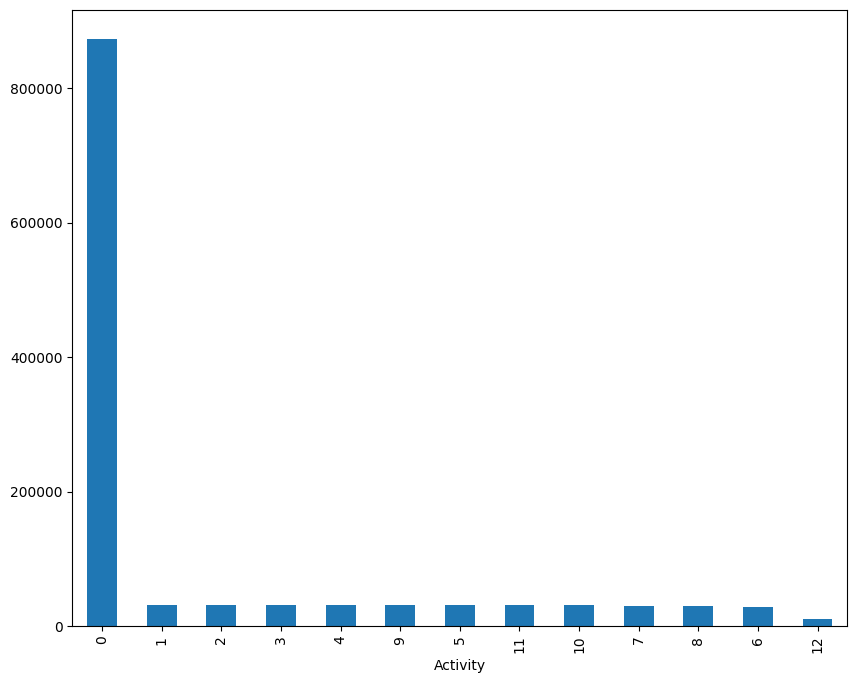

In [ ]:
plt.figure(figsize=(10,8))
df["Activity"].value_counts().plot.bar()

In [ ]:
data_activity_0 = df[df["Activity"] == 0]
data_activity_else = df[df["Activity"] != 0]

data_activity_0 = data_activity_0.sample(n=40000)
df = pd.concat([data_activity_0, data_activity_else])

<Axes: xlabel='Activity'>

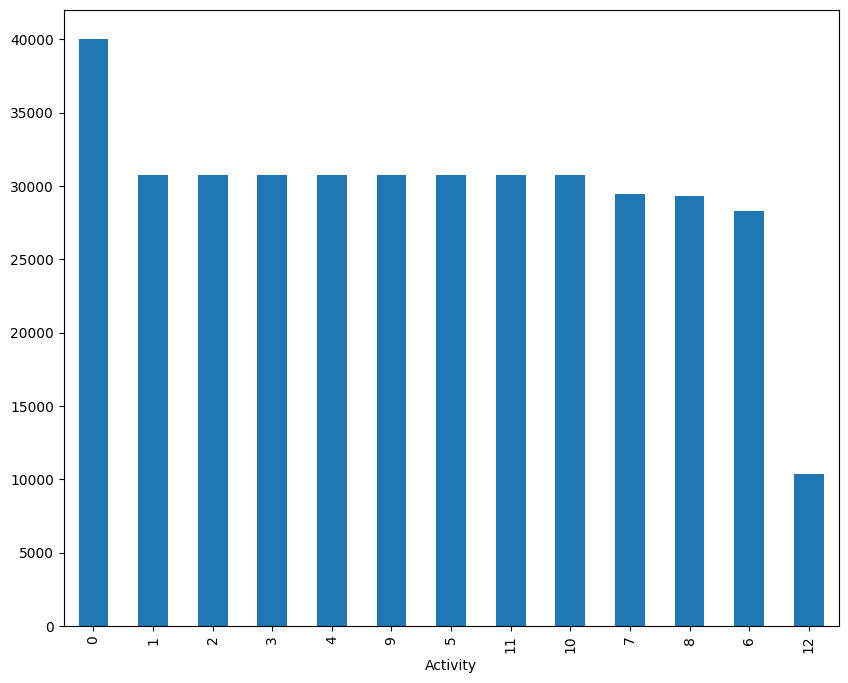

In [ ]:
plt.figure(figsize=(10,8))
df["Activity"].value_counts().plot.bar()

In [ ]:
len(df)

383195

In [ ]:
activity_label = {
    0: "None",
    1: "Standing still (1 min)",
    2: "Sitting and relaxing (1 min)",
    3: "Lying down (1 min)",
    4: "Walking (1 min)",
    5: "Climbing stairs (1 min)",
    6: "Waist bends forward (20x)",
    7: "Frontal elevation of arms (20x)",
    8: "Knees bending (crouching) (20x)",
    9: "Cycling (1 min)",
    10: "Jogging (1 min)",
    11: "Running (1 min)",
    12: "Jump front & back (20x)"
}

=====================Standing still (1 min) - a=====================


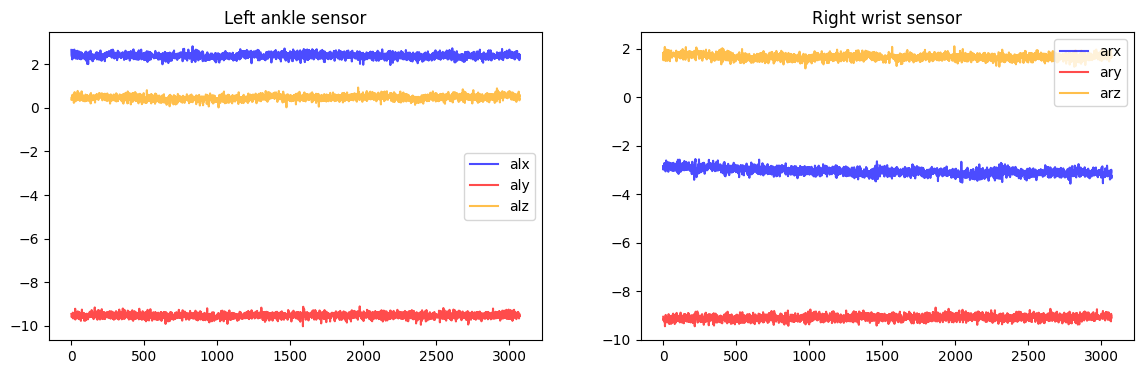

=====================Standing still (1 min) - g=====================


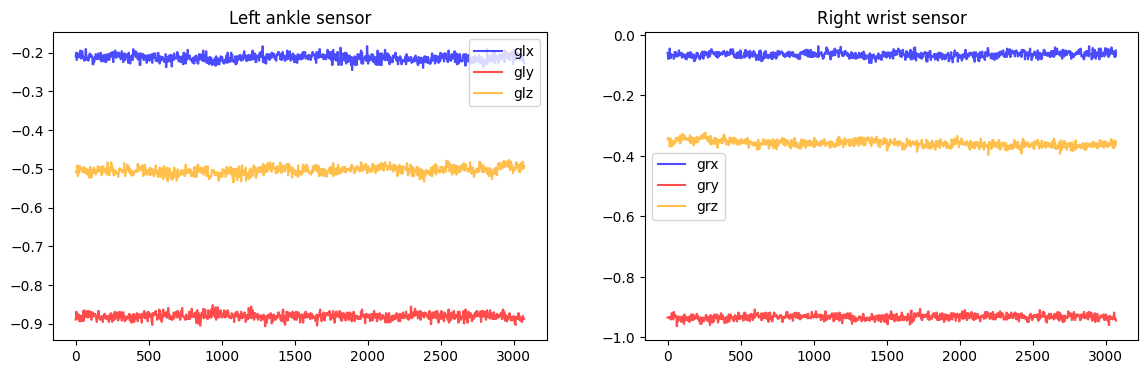

=====================Sitting and relaxing (1 min) - a=====================


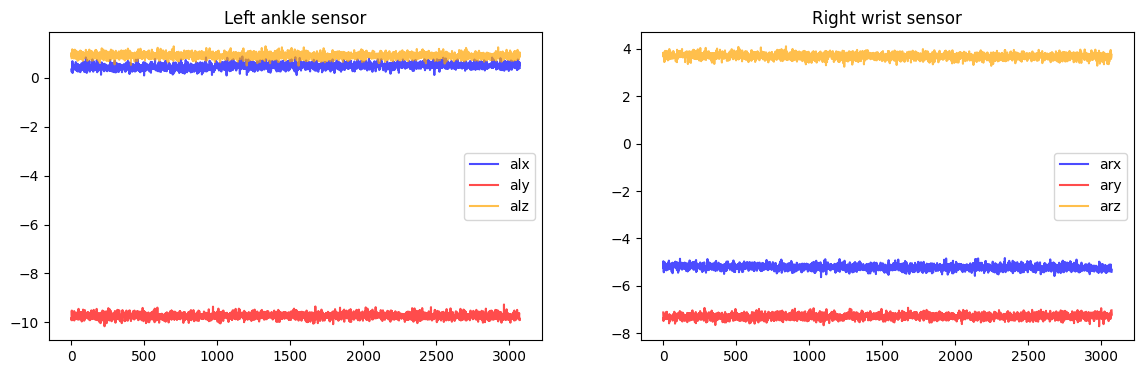

=====================Sitting and relaxing (1 min) - g=====================


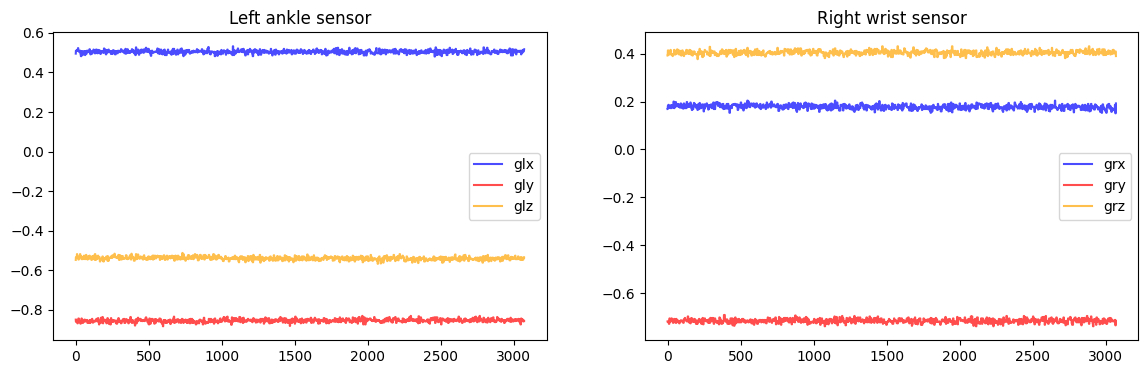

=====================Lying down (1 min) - a=====================


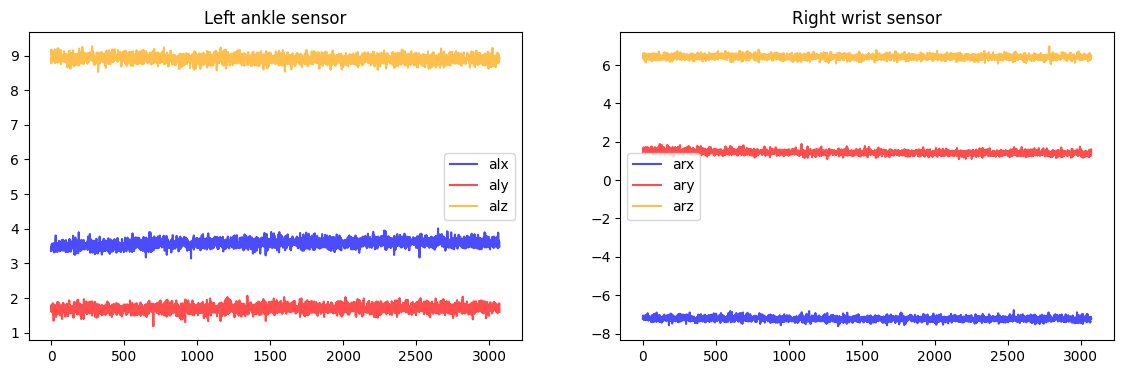

=====================Lying down (1 min) - g=====================


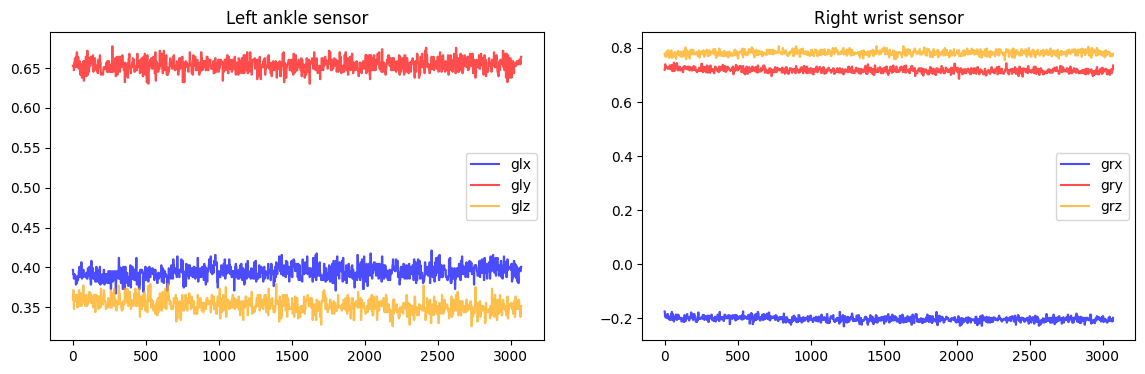

=====================Walking (1 min) - a=====================


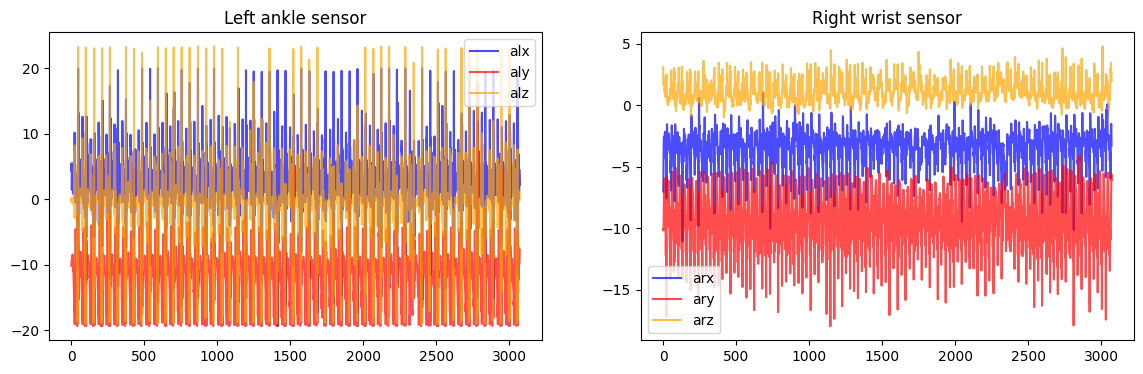

=====================Walking (1 min) - g=====================


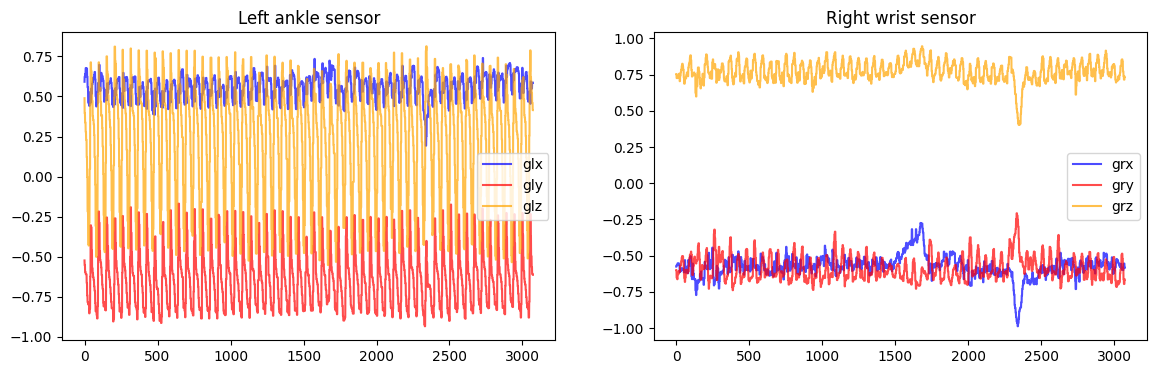

=====================Climbing stairs (1 min) - a=====================


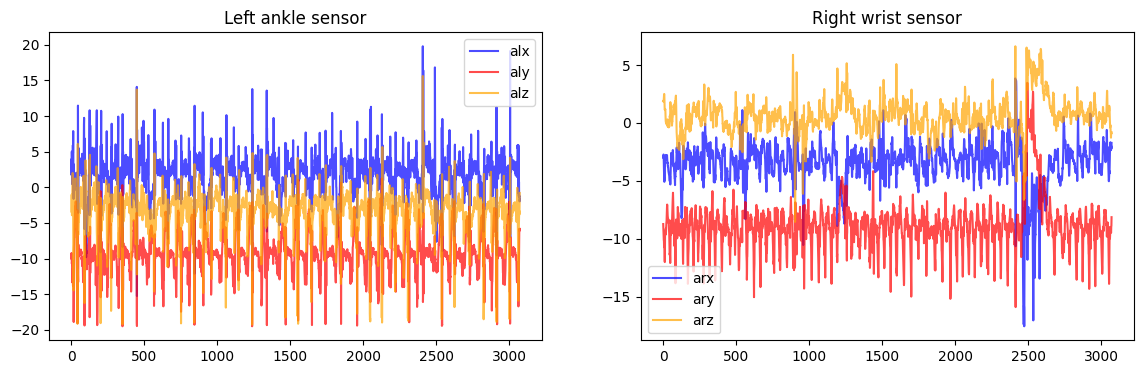

=====================Climbing stairs (1 min) - g=====================


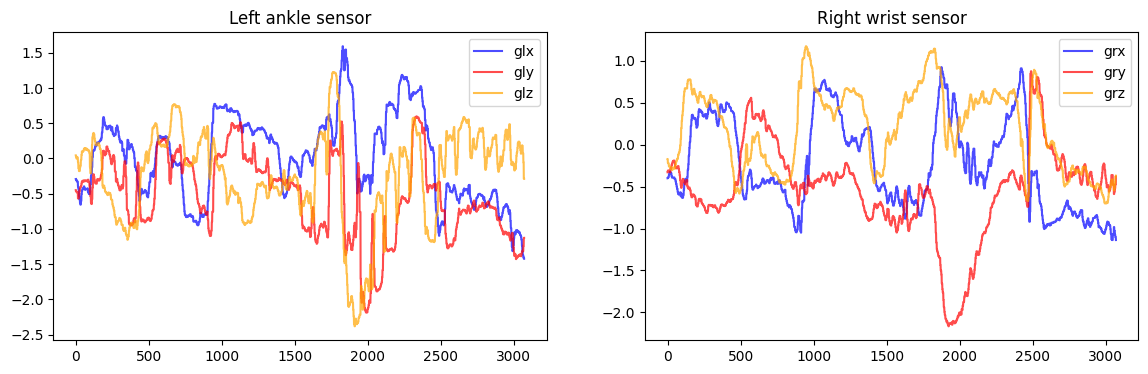

=====================Waist bends forward (20x) - a=====================


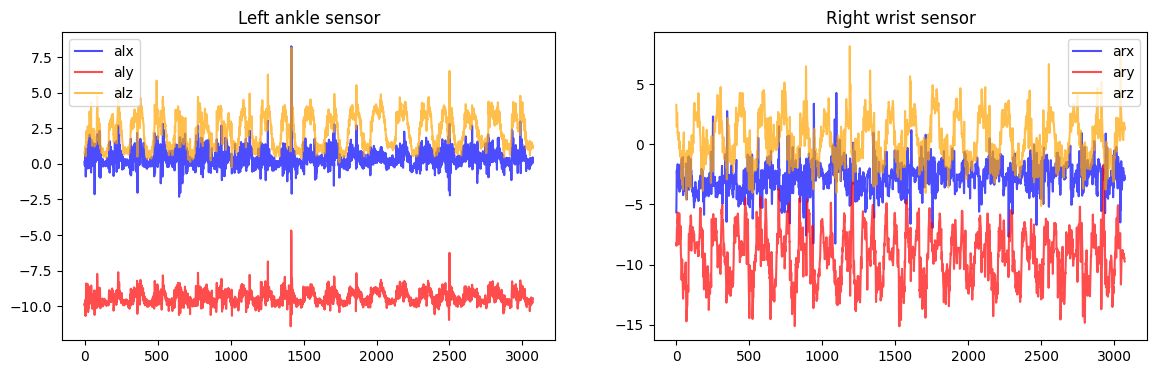

=====================Waist bends forward (20x) - g=====================


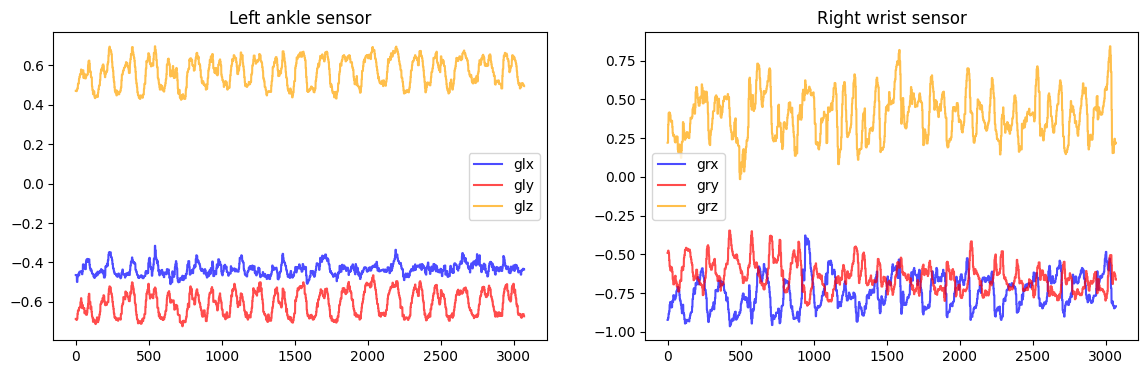

=====================Frontal elevation of arms (20x) - a=====================


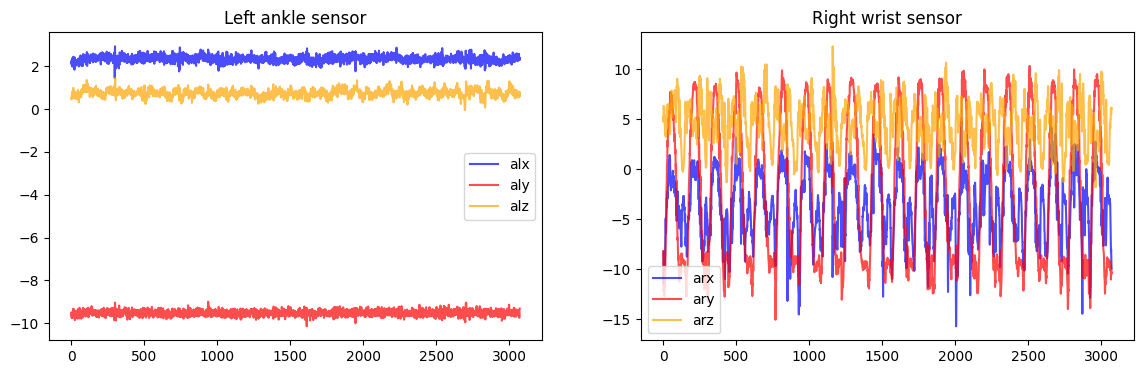

=====================Frontal elevation of arms (20x) - g=====================


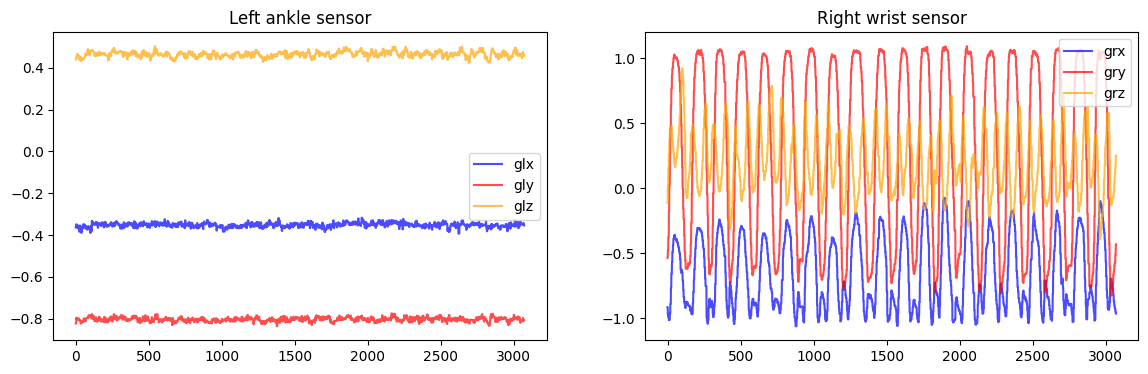

=====================Knees bending (crouching) (20x) - a=====================


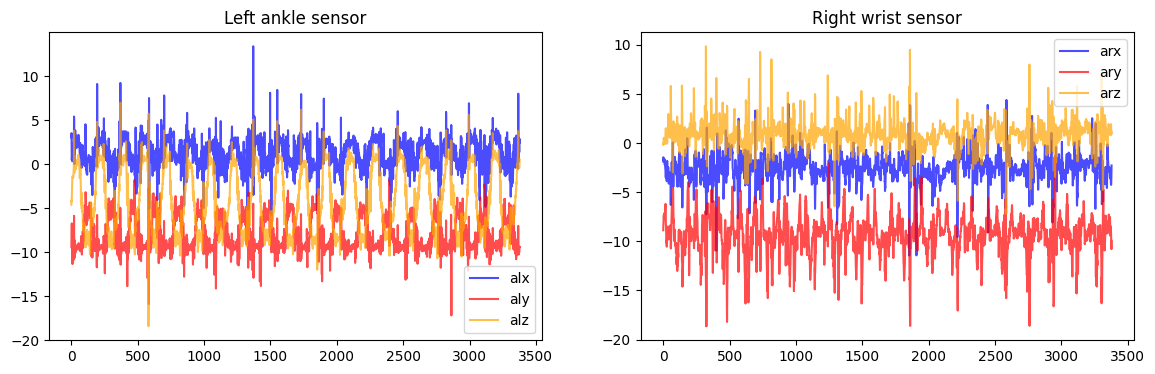

=====================Knees bending (crouching) (20x) - g=====================


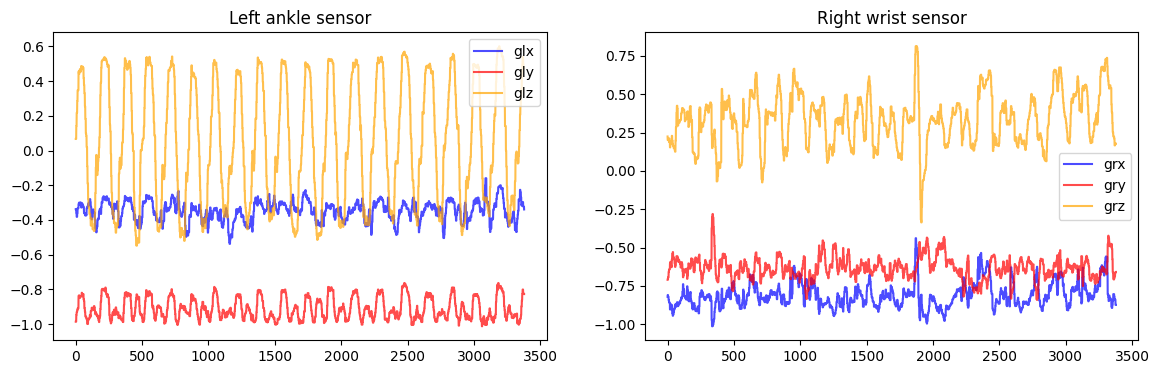

=====================Cycling (1 min) - a=====================


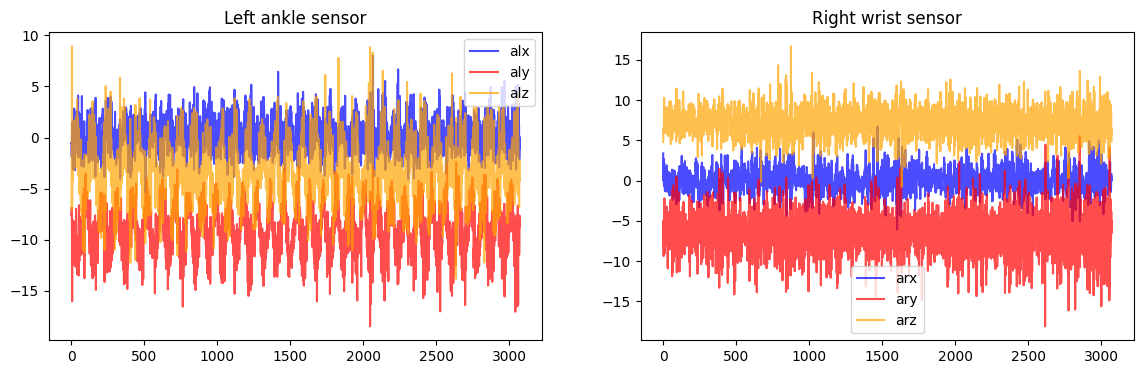

=====================Cycling (1 min) - g=====================


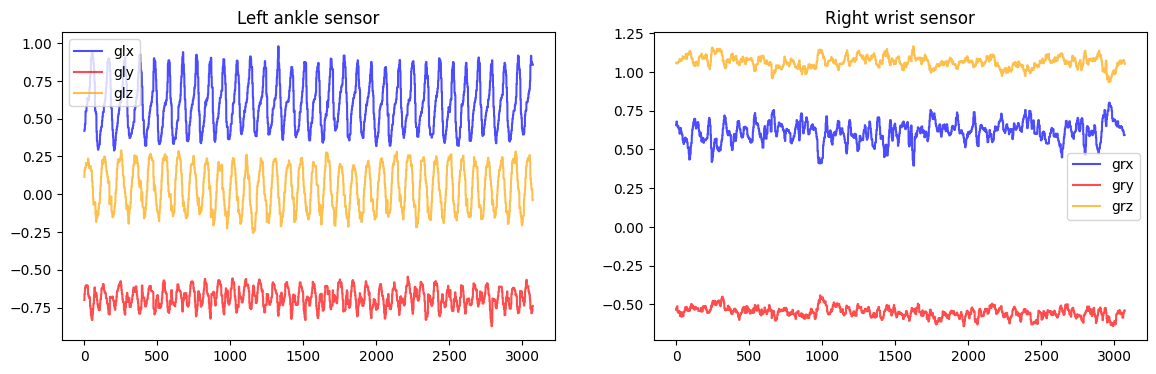

=====================Jogging (1 min) - a=====================


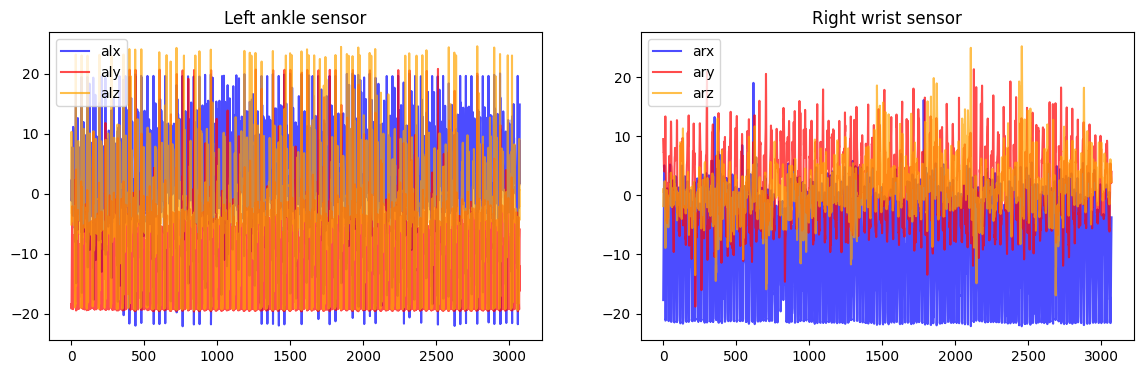

=====================Jogging (1 min) - g=====================


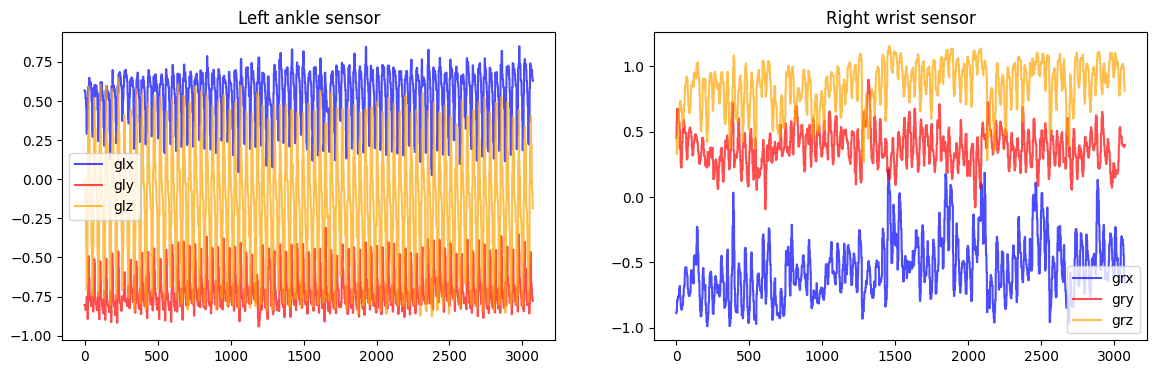

=====================Running (1 min) - a=====================


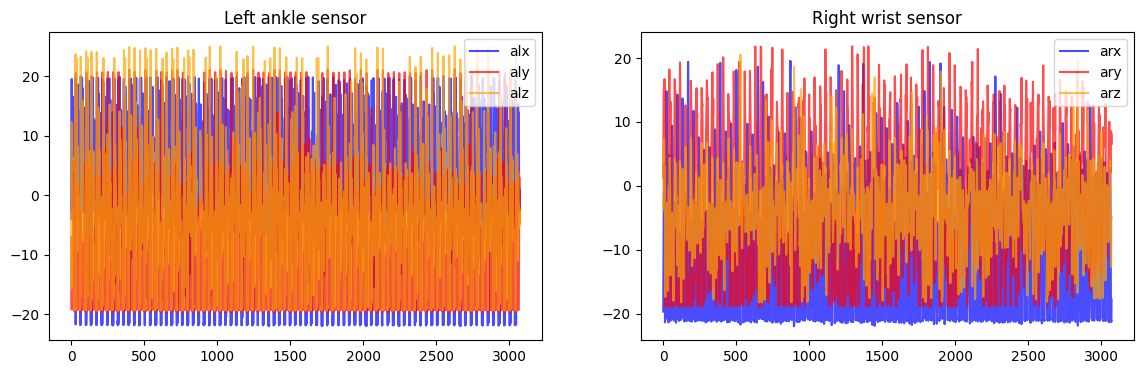

=====================Running (1 min) - g=====================


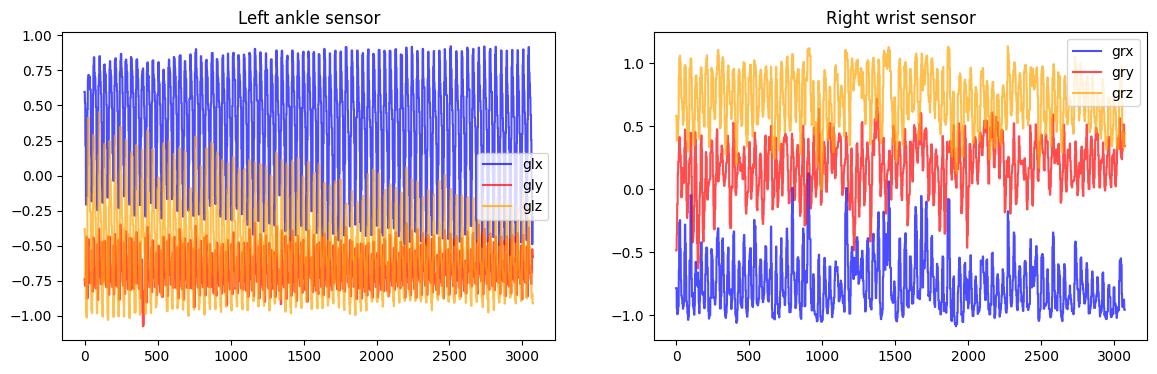

=====================Jump front & back (20x) - a=====================


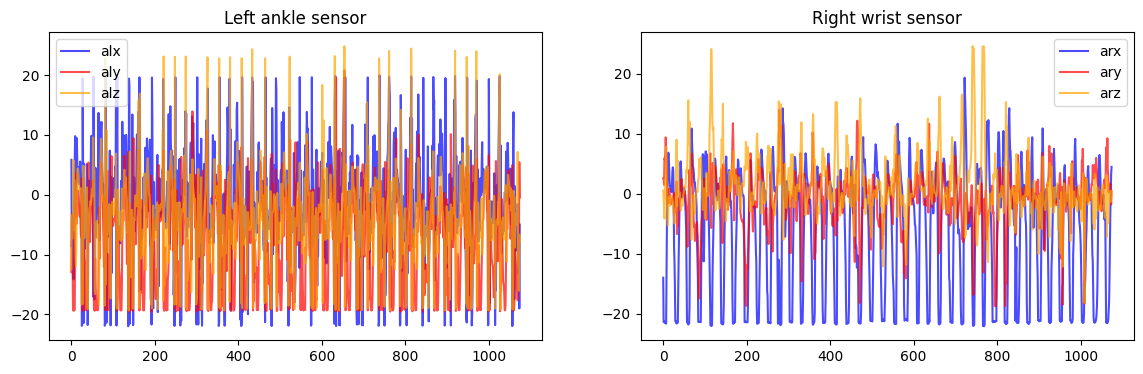

=====================Jump front & back (20x) - g=====================


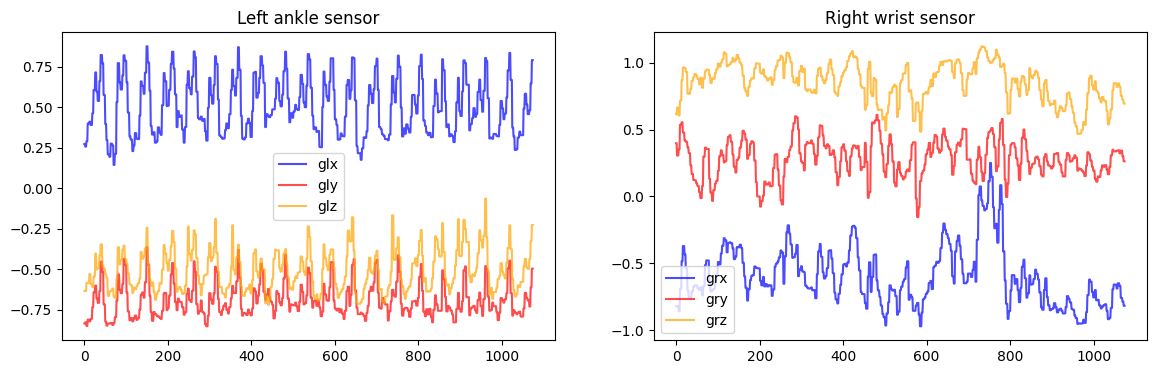

In [ ]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']

for i in range(1, 13):
    for r in readings:
        print(f"====================={activity_label[i]} - {r}=====================")
        plt.figure(figsize=(14, 4))
        plt.subplot(1, 2, 1)
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
                 color='blue', alpha=0.7, label=r + "lx")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
                 color='red', alpha=0.7, label=r + "ly")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
                 color='orange', alpha=0.7, label=r + "lz")
        plt.title("Left ankle sensor")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
                 color='blue', alpha=0.7, label=r + "rx")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
                 color='red', alpha=0.7, label=r + "ry")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
                 color='orange', alpha=0.7, label=r + "rz")
        plt.title("Right wrist sensor")
        plt.legend()
        plt.show()

=====================Standing still (1 min) - a=====================


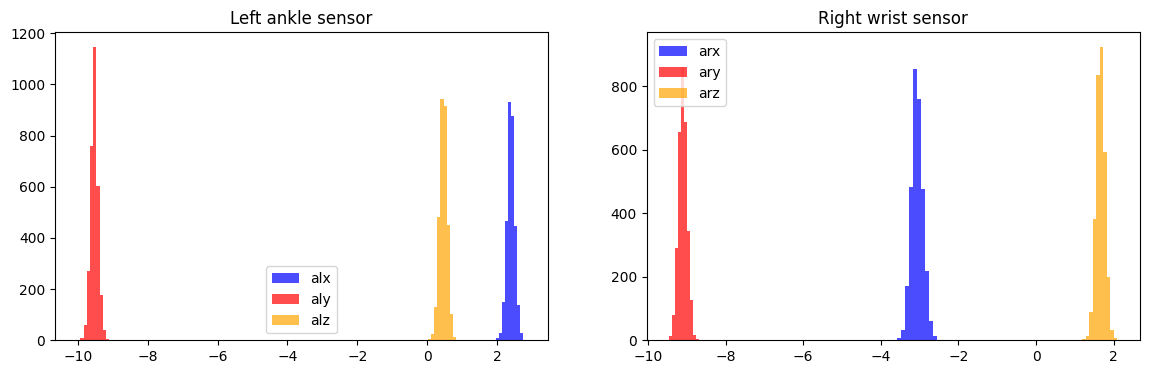

=====================Standing still (1 min) - g=====================


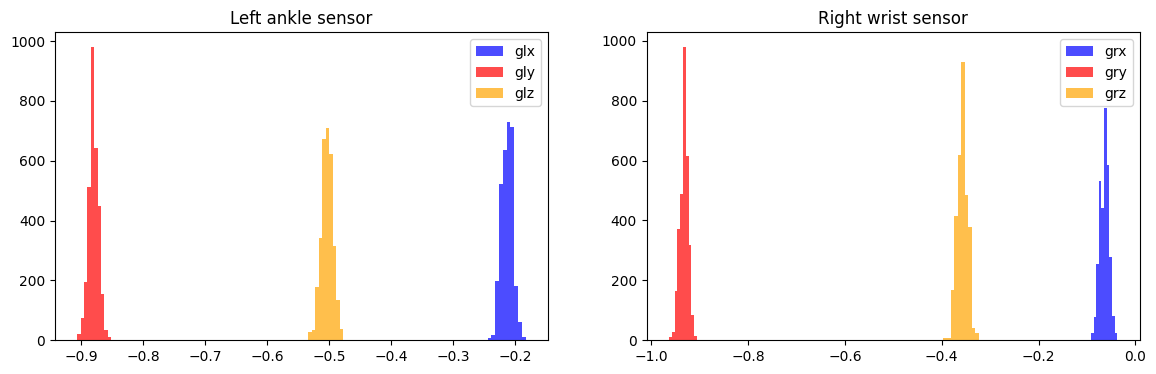

=====================Sitting and relaxing (1 min) - a=====================


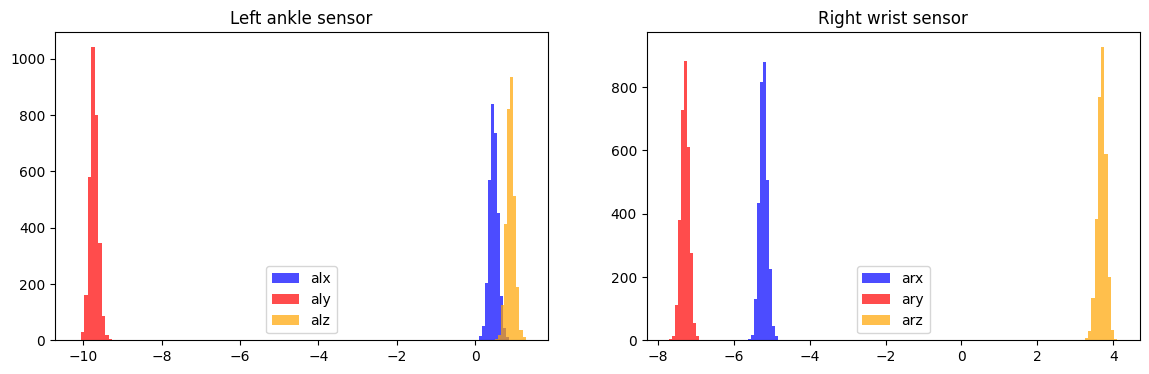

=====================Sitting and relaxing (1 min) - g=====================


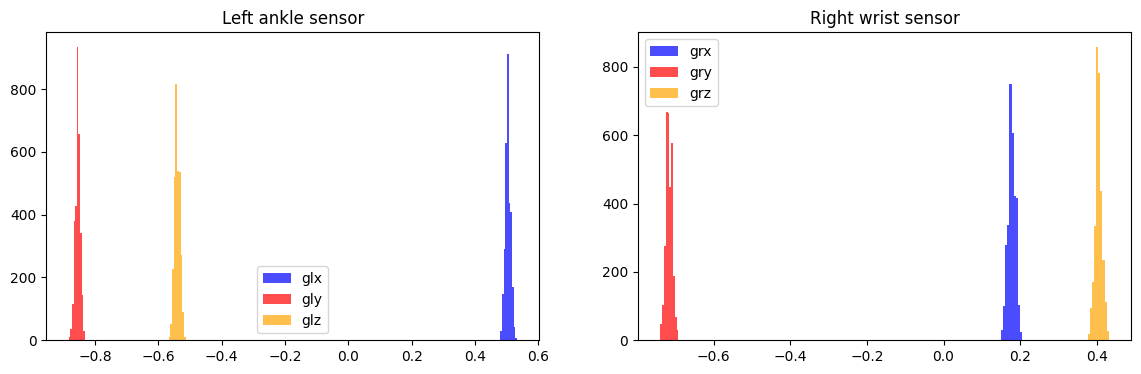

=====================Lying down (1 min) - a=====================


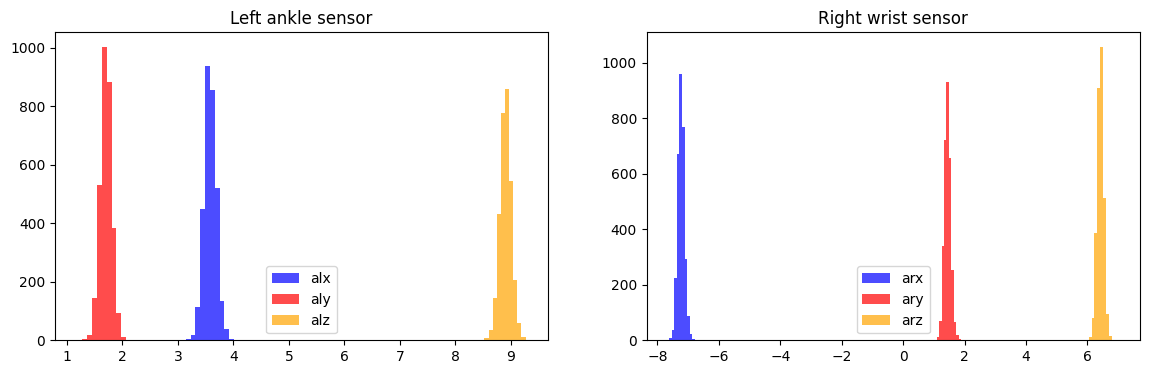

=====================Lying down (1 min) - g=====================


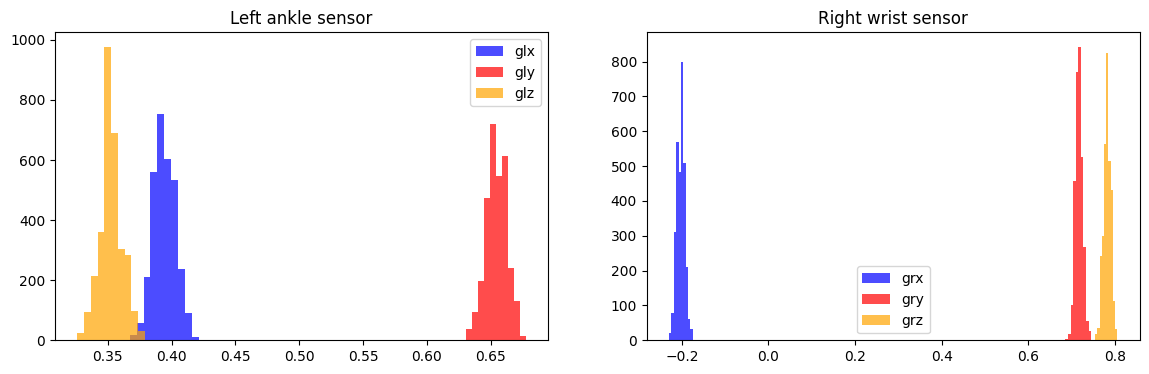

=====================Walking (1 min) - a=====================


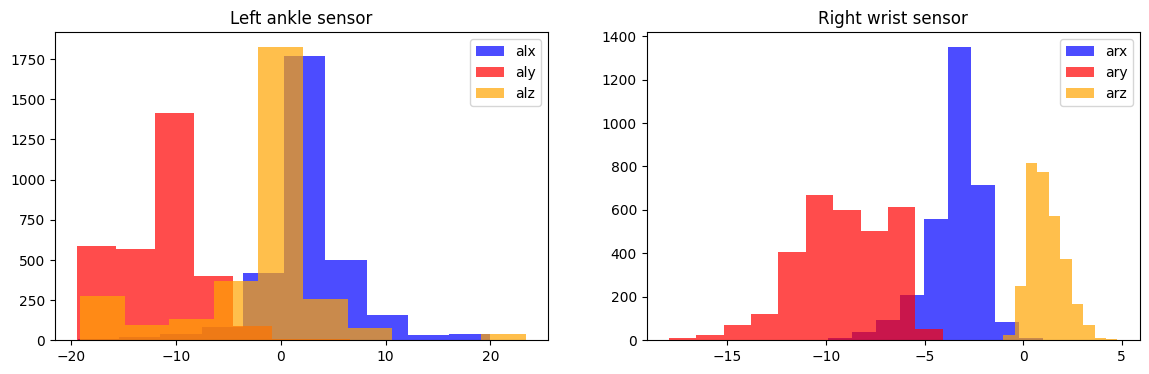

=====================Walking (1 min) - g=====================


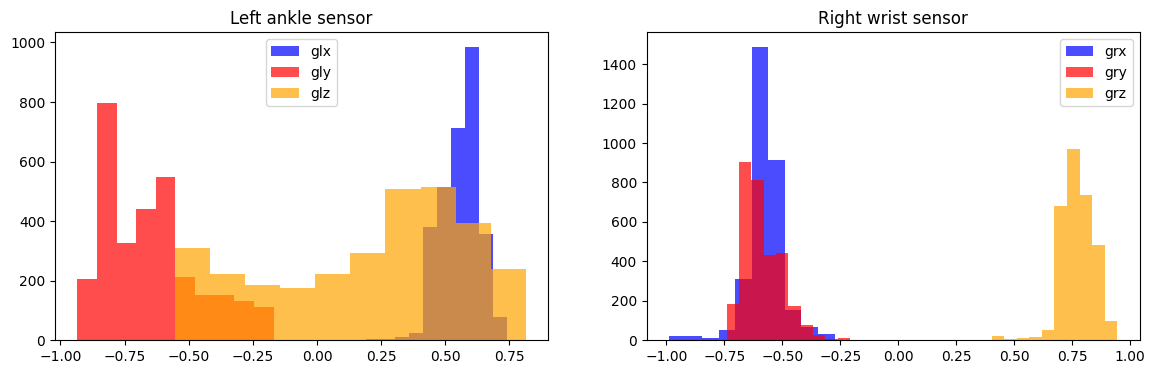

=====================Climbing stairs (1 min) - a=====================


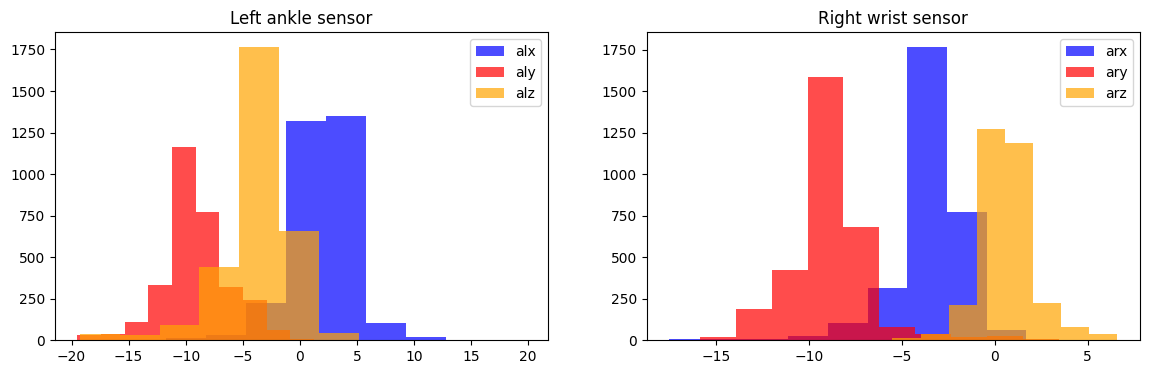

=====================Climbing stairs (1 min) - g=====================


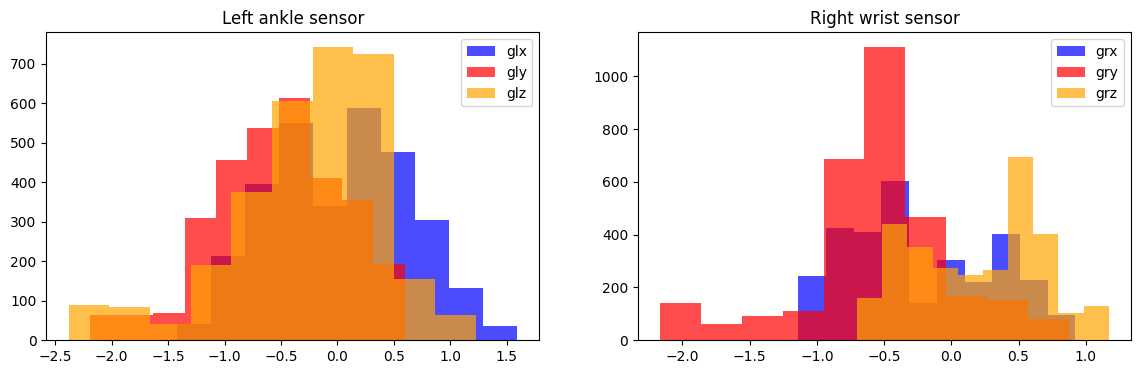

=====================Waist bends forward (20x) - a=====================


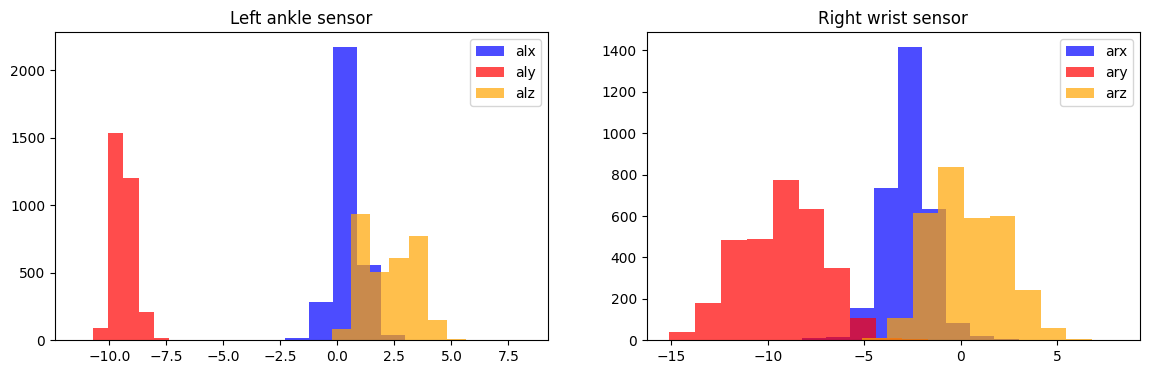

=====================Waist bends forward (20x) - g=====================


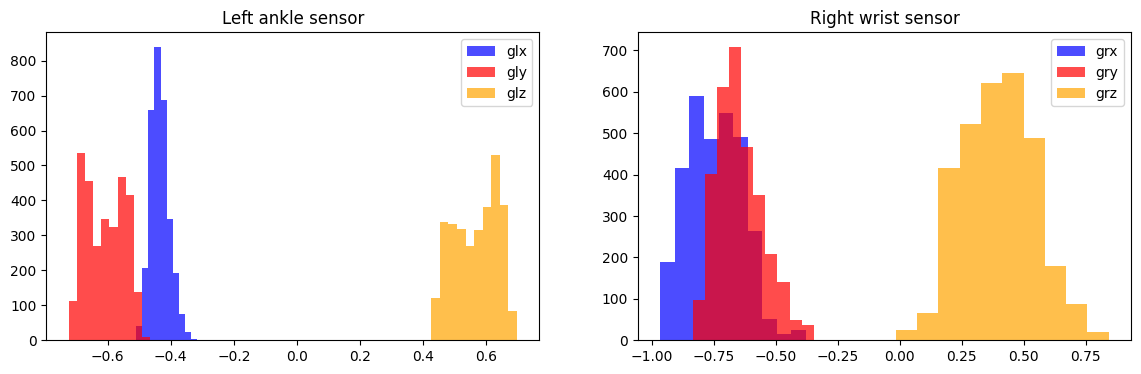

=====================Frontal elevation of arms (20x) - a=====================


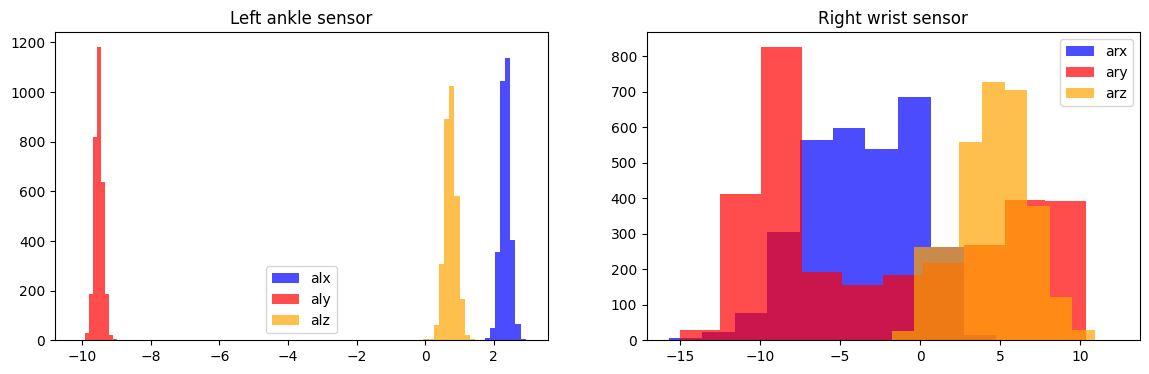

=====================Frontal elevation of arms (20x) - g=====================


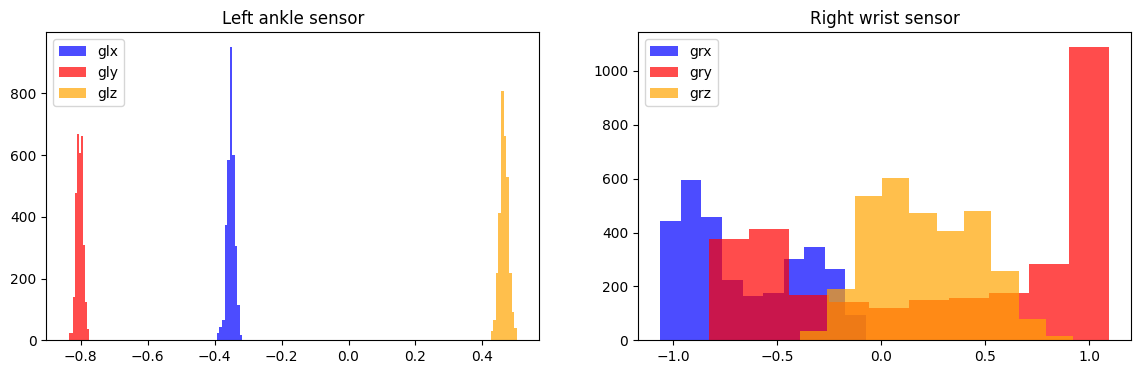

=====================Knees bending (crouching) (20x) - a=====================


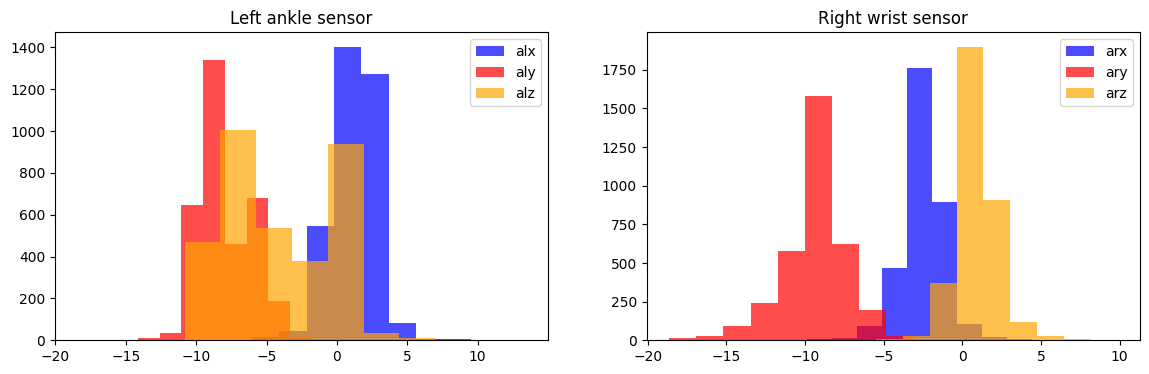

=====================Knees bending (crouching) (20x) - g=====================


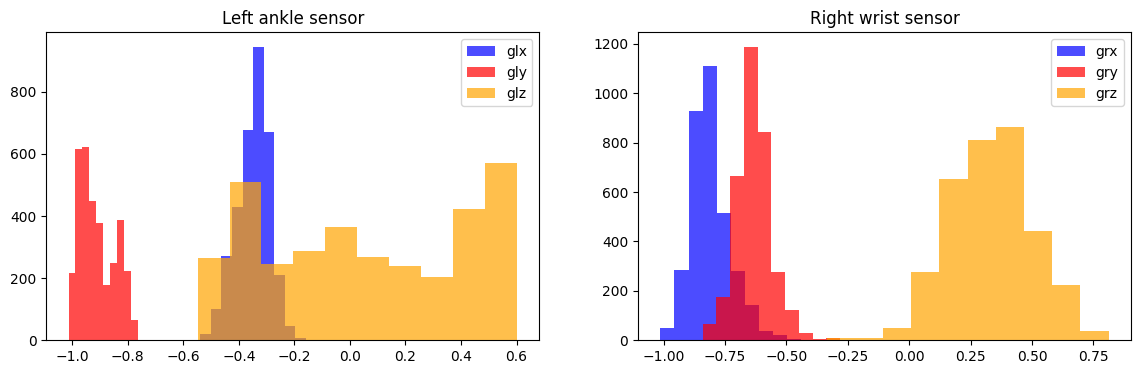

=====================Cycling (1 min) - a=====================


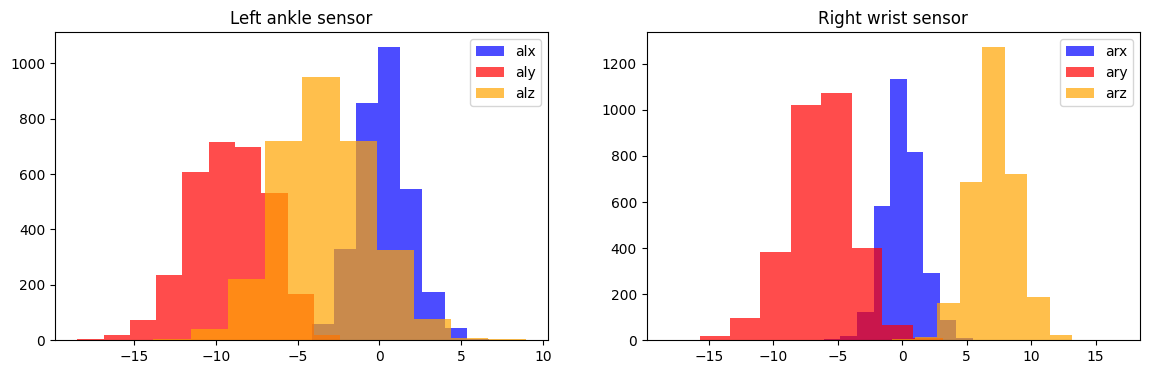

=====================Cycling (1 min) - g=====================


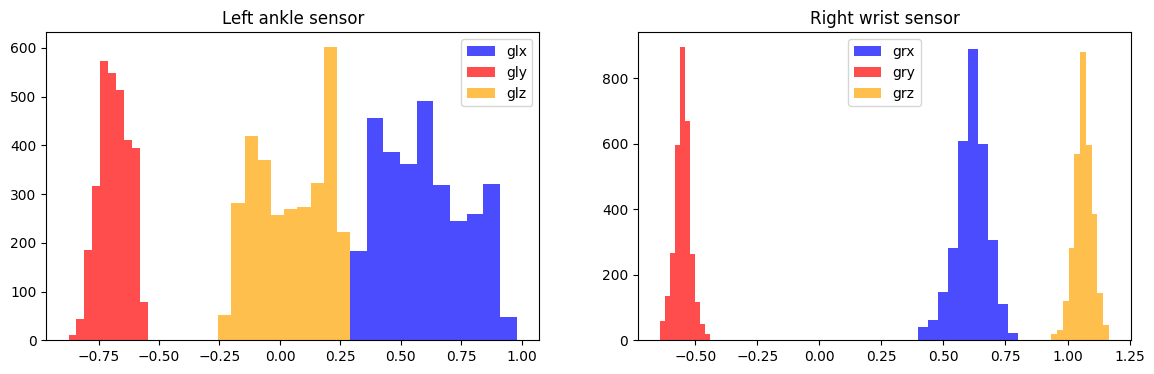

=====================Jogging (1 min) - a=====================


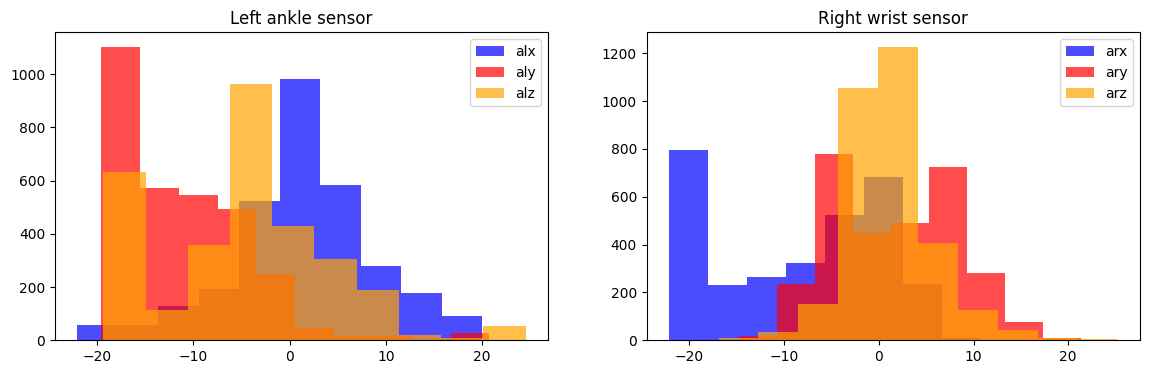

=====================Jogging (1 min) - g=====================


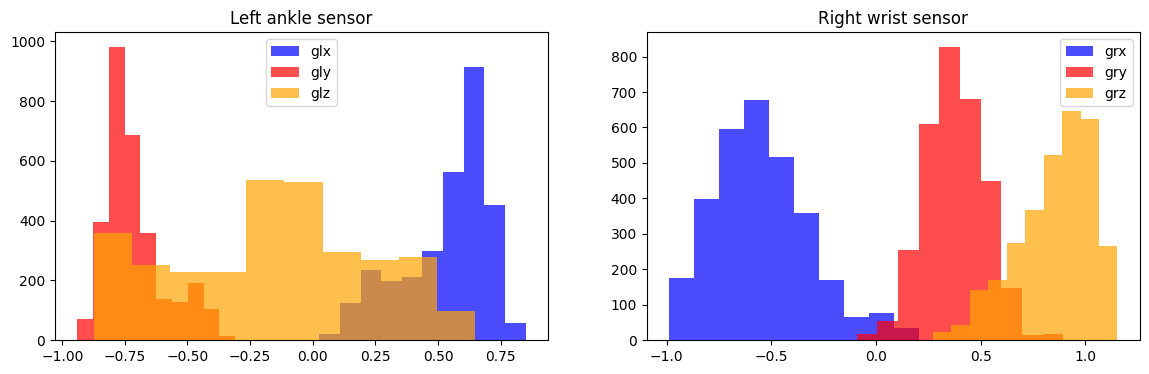

=====================Running (1 min) - a=====================


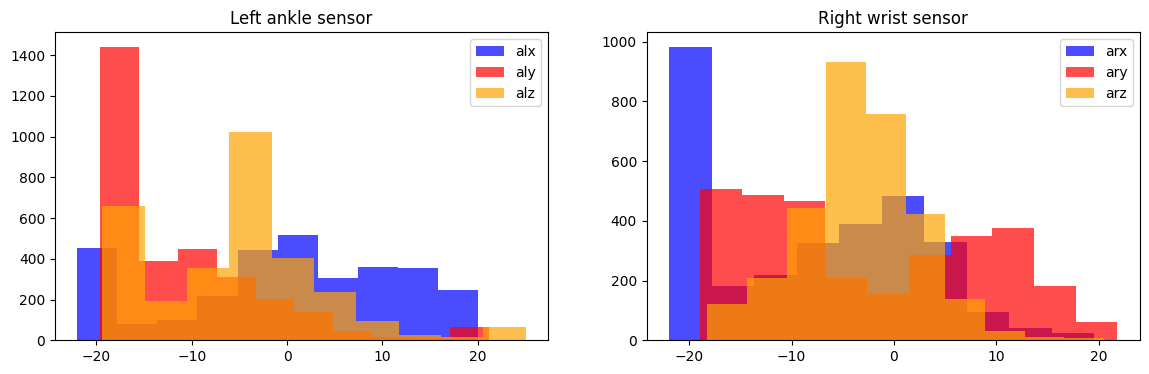

=====================Running (1 min) - g=====================


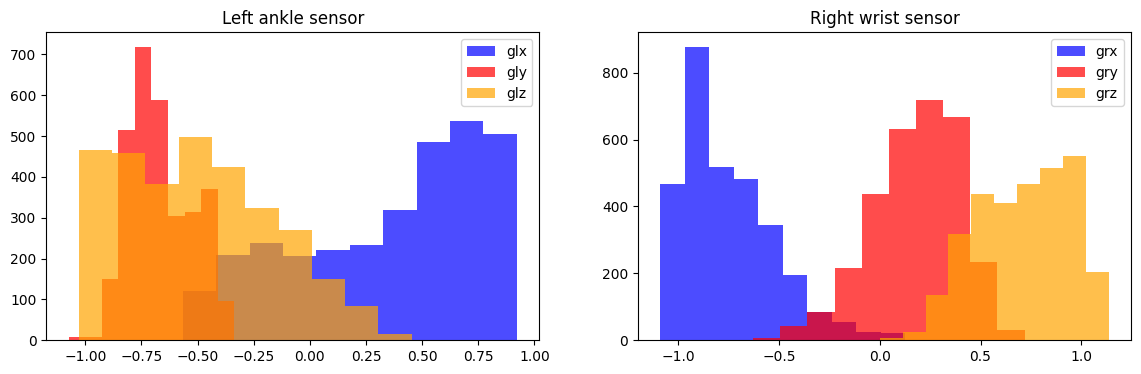

=====================Jump front & back (20x) - a=====================


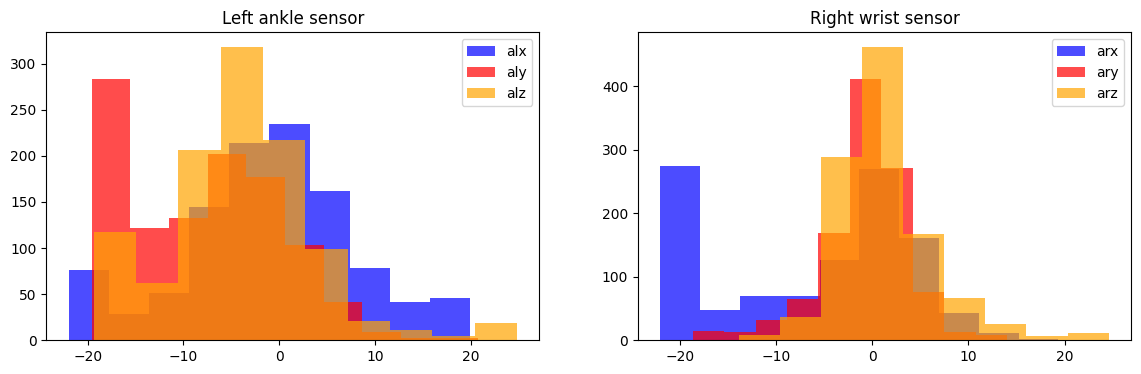

=====================Jump front & back (20x) - g=====================


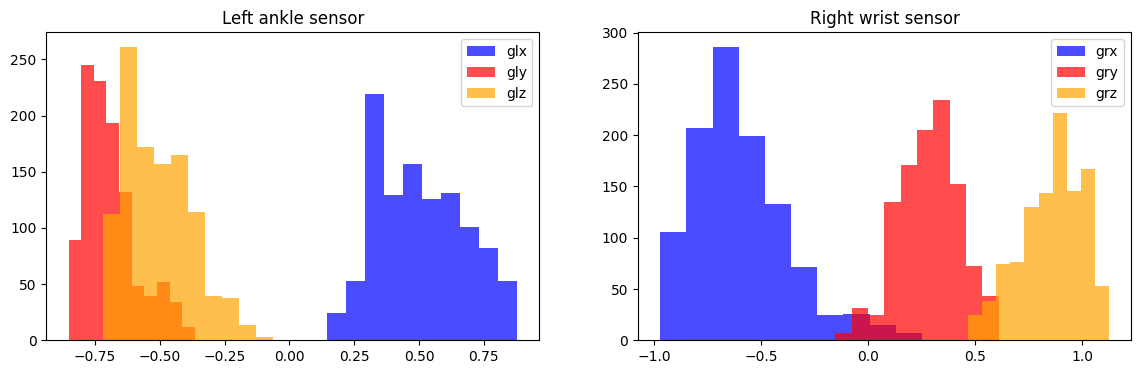

In [ ]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']

for i in range(1, 13):
    for r in readings:
        print(f"====================={activity_label[i]} - {r}=====================")
        plt.figure(figsize=(14, 4))
        plt.subplot(1, 2, 1)
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
                 color='blue', alpha=0.7, label=r + "lx")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
                 color='red', alpha=0.7, label=r + "ly")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
                 color='orange', alpha=0.7, label=r + "lz")
        plt.title("Left ankle sensor")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
                 color='blue', alpha=0.7, label=r + "rx")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
                 color='red', alpha=0.7, label=r + "ry")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
                 color='orange', alpha=0.7, label=r + "rz")
        plt.title("Right wrist sensor")
        plt.legend()
        plt.show()

In [ ]:
df["Activity"] = df["Activity"].replace(
    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    [
        "None",
        "Standing still (1 min)",
        "Sitting and relaxing (1 min)",
        "Lying down (1 min)",
        "Walking (1 min)",
        "Climbing stairs (1 min)",
        "Waist bends forward (20x)",
        "Frontal elevation of arms (20x)",
        "Knees bending (crouching) (20x)",
        "Cycling (1 min)",
        "Jogging (1 min)",
        "Running (1 min)",
        "Jump front & back (20x)"
    ]
)

<Axes: ylabel='count'>

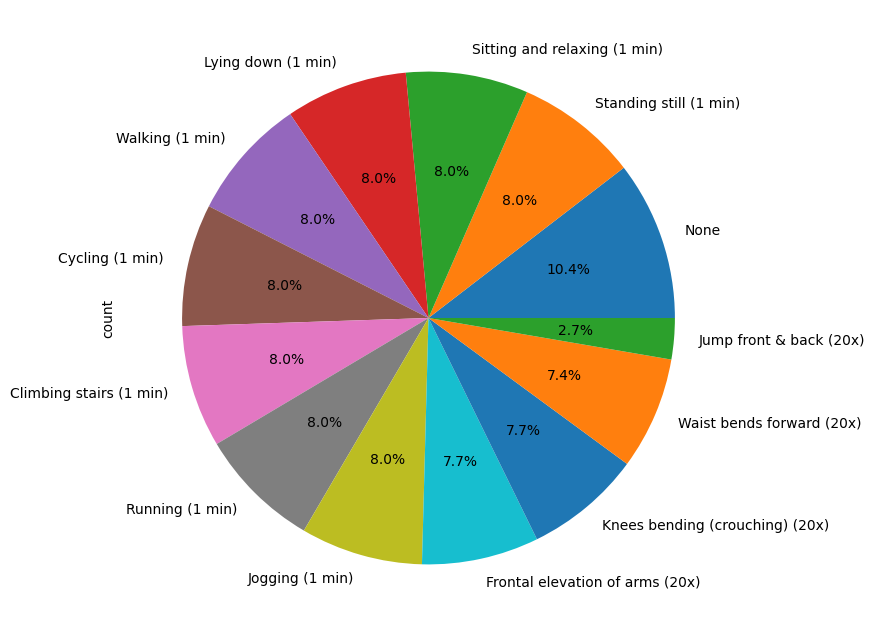

In [ ]:
plt.figure(figsize=(12, 8))

round(df["Activity"].value_counts() / df.shape[0] * 100, 2).plot.pie(
    autopct="%2.1f%%"
)

In [ ]:
df1 = df.copy()

for feature in df1.columns[:-2]:
    lower_range = np.quantile(df[feature], 0.01)
    upper_range = np.quantile(df[feature], 0.99)

    print(feature, "range:", lower_range, "to", upper_range)

    df1 = df1.drop(
        df1[
            (df1[feature] > upper_range) |
            (df1[feature] < lower_range)
        ].index,
        axis=0
    )

    print("shape", df1.shape)

alx range: -11.53506 to 19.223
shape (375537, 14)
aly range: -19.378 to 2.371906
shape (369621, 14)
alz range: -18.949 to 14.126119999999995
shape (365805, 14)
glx range: -0.75325 to 0.80891
shape (358775, 14)
gly range: -1.0694 to 0.96623
shape (352140, 14)
glz range: -1.1061 to 0.8290799999999999
shape (346494, 14)
arx range: -21.487 to 9.02563
shape (341271, 14)
ary range: -18.691 to 11.828059999999997
shape (335061, 14)
arz range: -10.26506 to 11.767059999999997
shape (332397, 14)
grx range: -1.0216 to 0.95294
shape (328810, 14)
gry range: -1.1437 to 0.91376
shape (323772, 14)
grz range: -0.7069 to 1.125
shape (319094, 14)


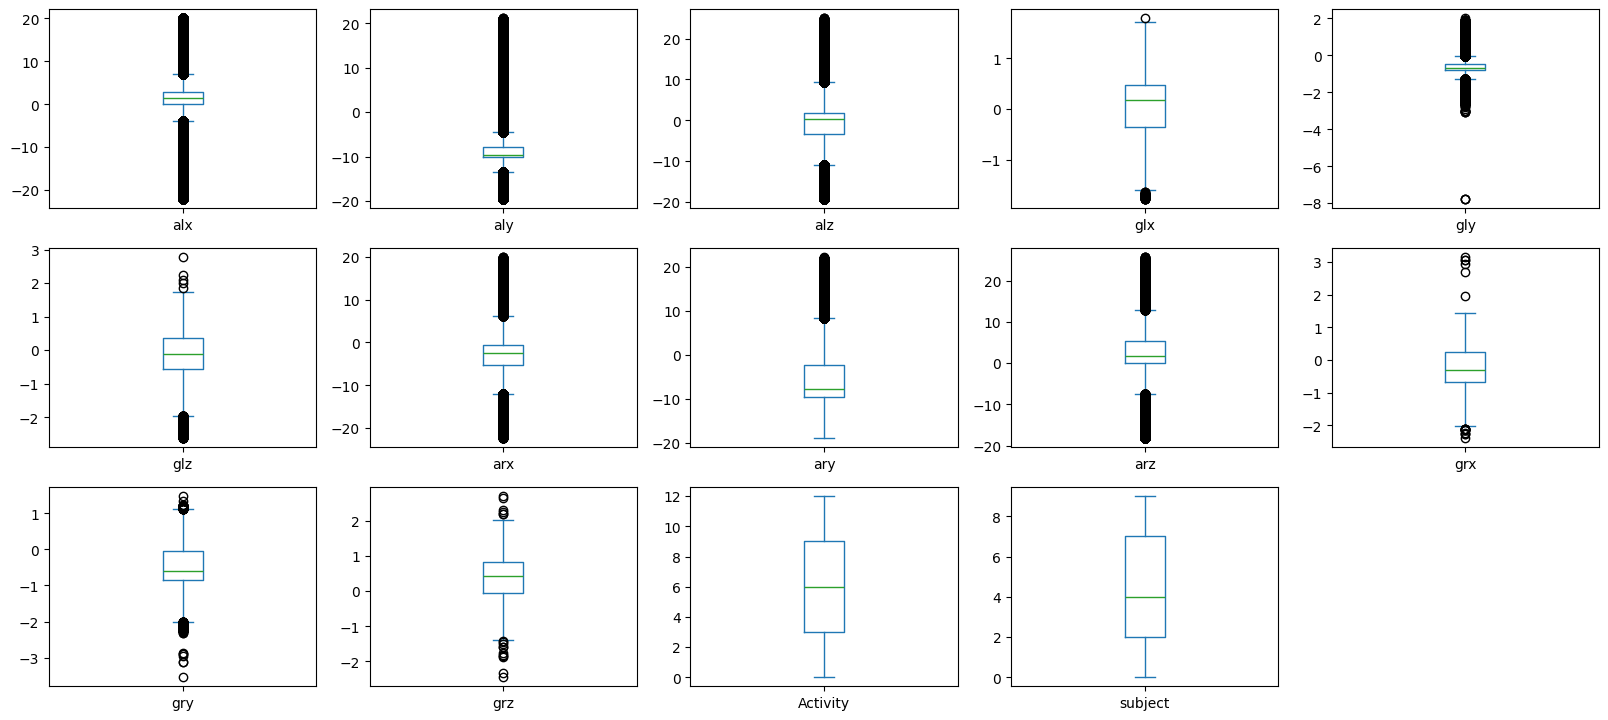

In [ ]:
le = LabelEncoder()

df["subject"] = le.fit_transform(df["subject"])
df["Activity"] = le.fit_transform(df["Activity"])

df.plot(kind="box", subplots=True, layout=(5,5), figsize=(20,15))
plt.show()

In [ ]:
X = df.drop(["Activity", "subject"], axis=1).values
y = df["Activity"].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25
)

ro_scaler = RobustScaler().fit(X_train)

X_train_scaled = ro_scaler.transform(X_train)
X_test_scaled = ro_scaler.transform(X_test)

In [ ]:
def resultsSummarizer(y_true, y_pred, cm_en=True):

    cm = confusion_matrix(y_true, y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = sensitivity = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    if cm_en:
        plt.figure(figsize=(15, 15))

        sns.heatmap(
            cm,
            annot=True,
            cmap="Blues",
            xticklabels=activity_label.values(),
            yticklabels=activity_label.values()
        )

        plt.title("Confusion Matrix")
        plt.show()

    print(f"Accuracy Score:  {'{:.4%}'.format(acc)}")
    print(f"Precision Score: {'{:.4%}'.format(prec)}")
    print(f"Recall Score:    {'{:.4%}'.format(rec)}")
    print(f"F1 Score:        {'{:.4%}'.format(f1)}")

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
lr.score(X_train, y_train)

0.5416602875474954

In [ ]:
lr.score(X_test, y_test)

0.5421664109228698

In [ ]:
lr2 = LogisticRegression()
lr2.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
lr2.score(X_train_scaled, y_train)

0.5521823546604685

In [ ]:
lr2.score(X_test_scaled, y_test)

0.5520099374732513

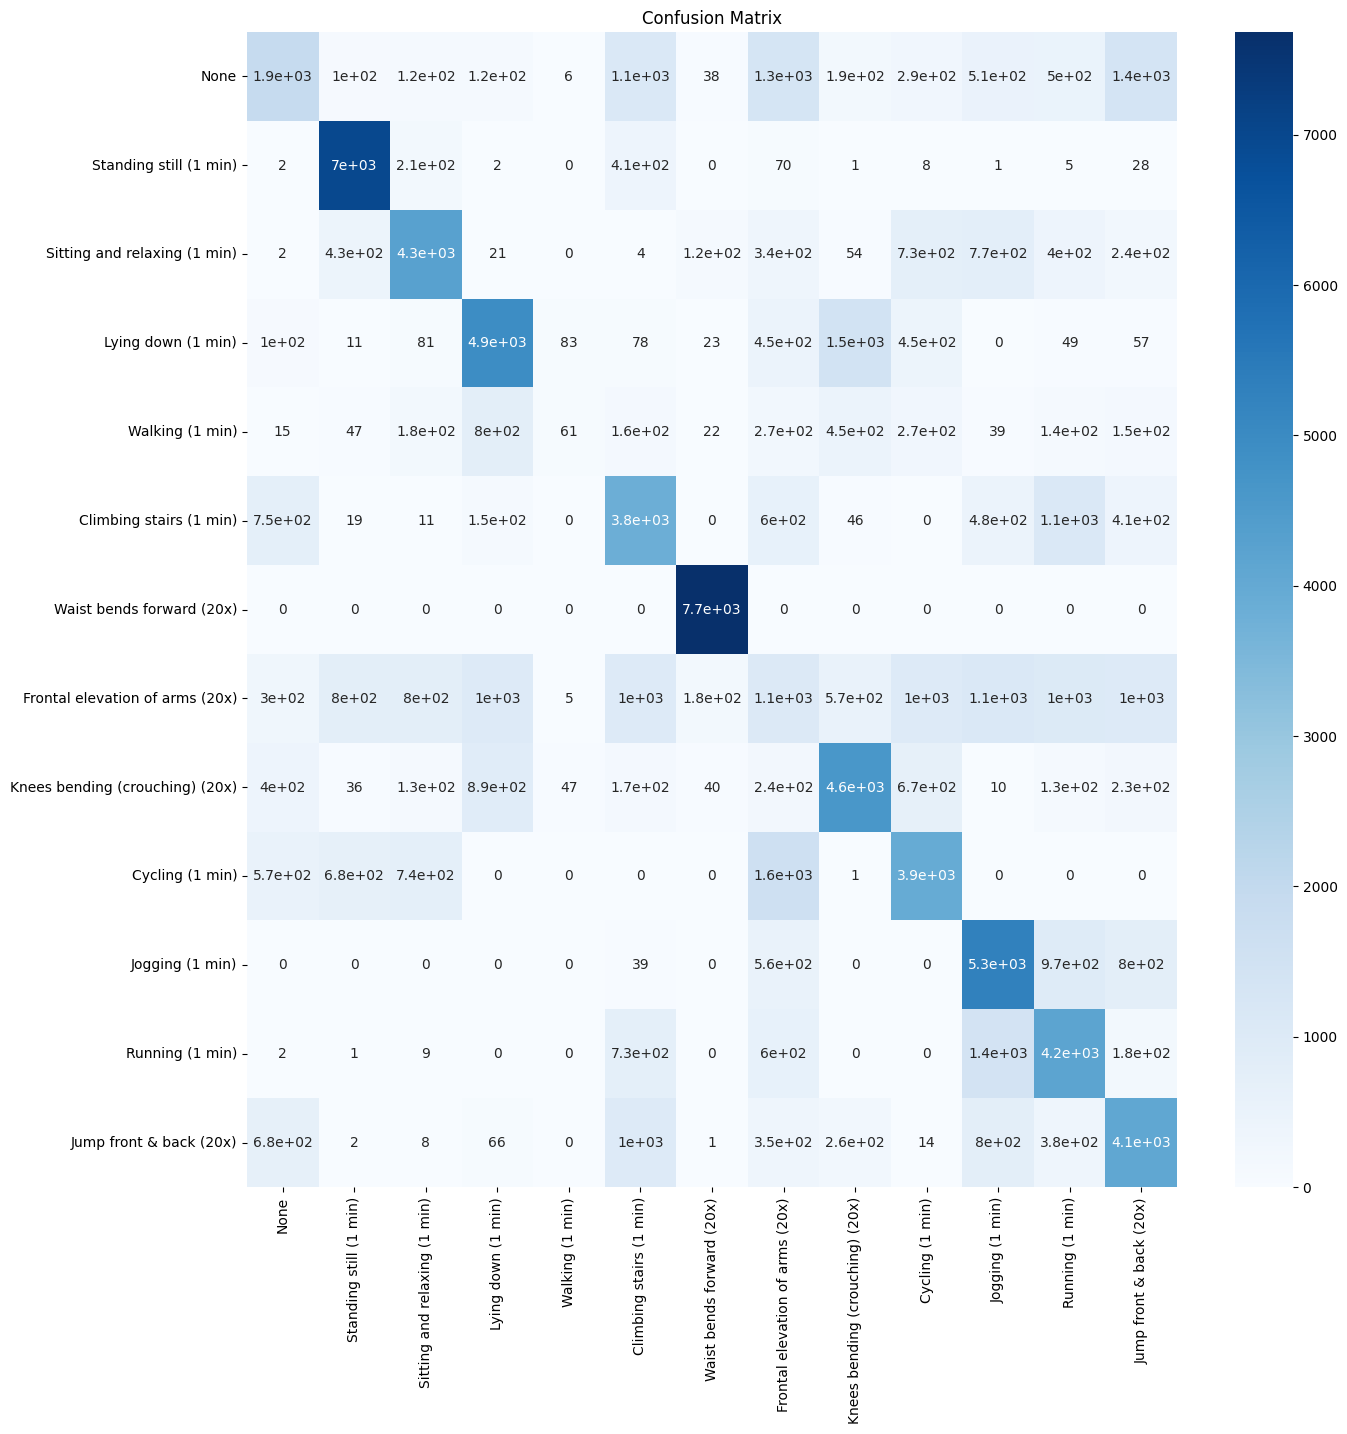

Accuracy Score: 55.2010%
Precision Score: 52.8304%
Recall Score: 53.5069%
F1 Score: 51.8349%


In [ ]:
y_pred_lr = lr2.predict(X_test_scaled)

resultsSummarizer(y_test, y_pred_lr)

In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train, y_train)

KNeighborsClassifier()

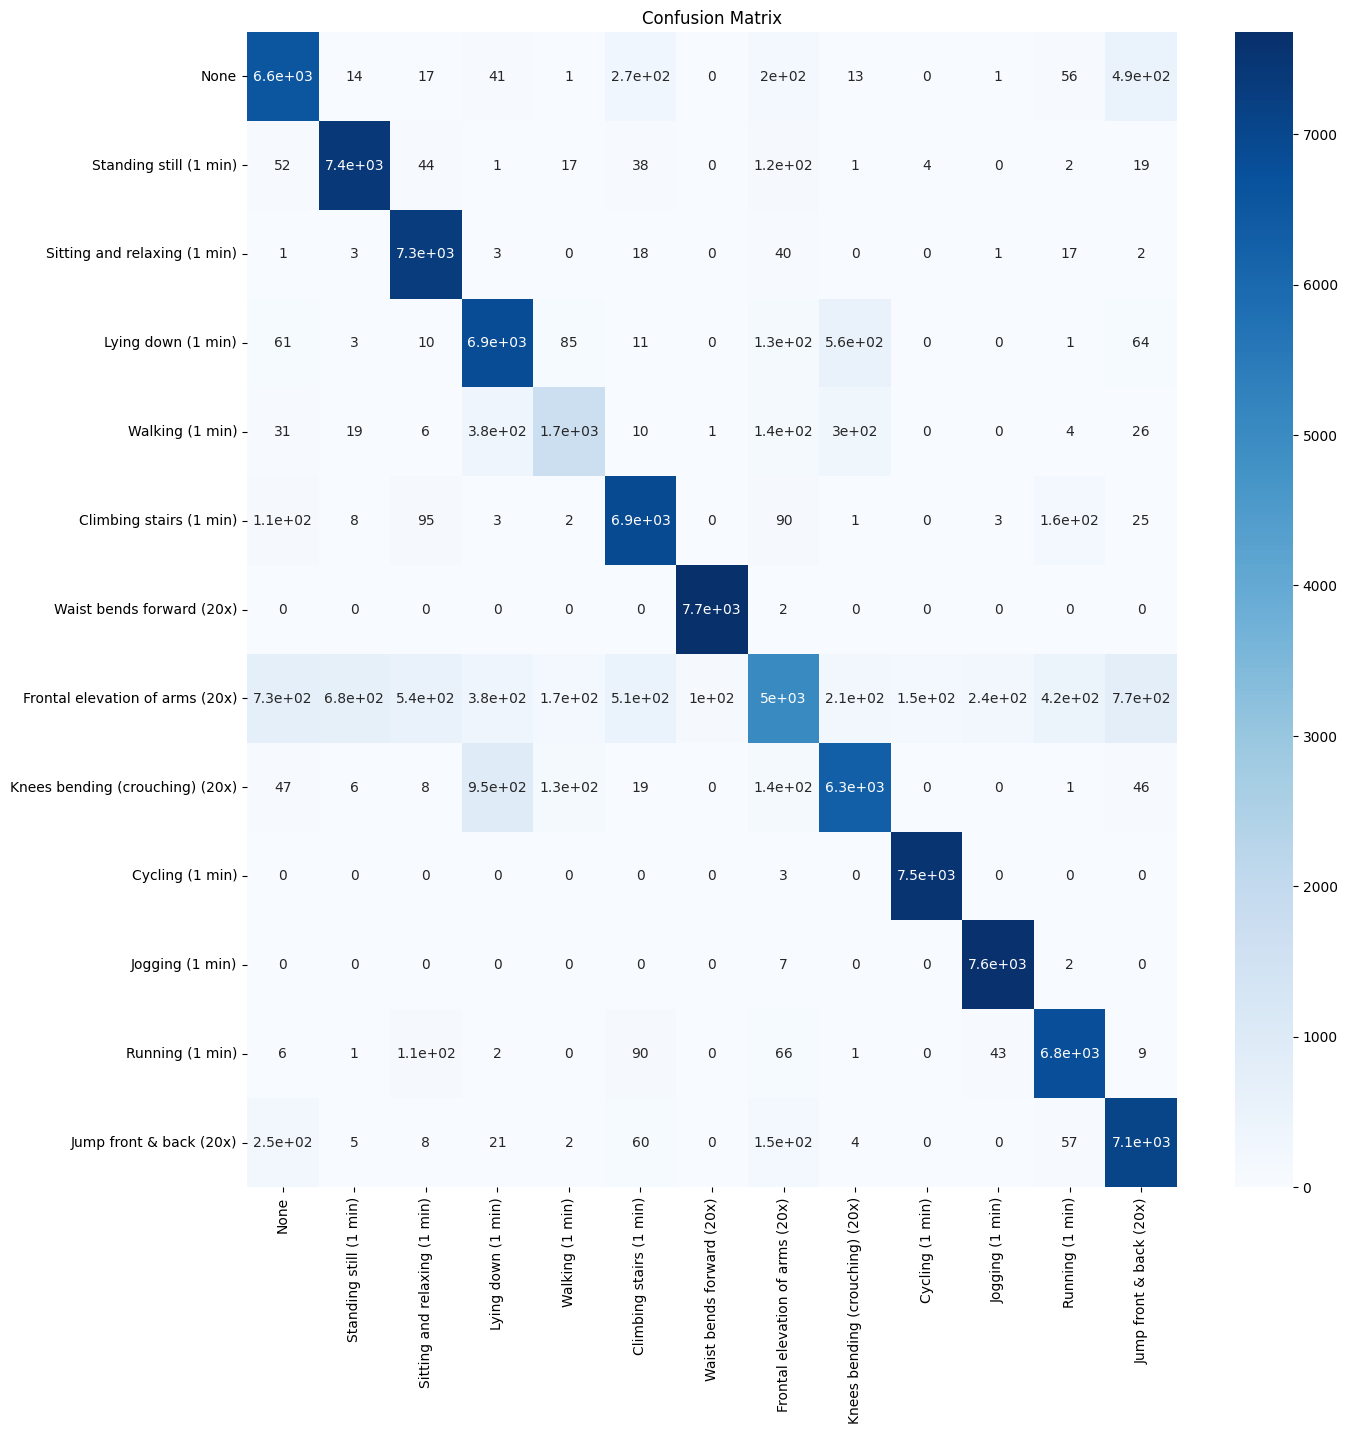

Accuracy Score: 88.5354%
Precision Score: 88.0883%
Recall Score: 88.2776%
F1 Score: 87.7420%


In [ ]:
y_pred_knn = knn1.predict(X_test)

resultsSummarizer(y_test, y_pred_knn)

In [ ]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_scaled, y_train)

y_pred_knn2 = knn2.predict(X_test_scaled)



In [ ]:
resultsSummarizer(y_test, y_pred_knn2, cm_en=False)

Accuracy Score:  93.7953%
Precision Score: 93.6603%
Recall Score:    93.6665%
F1 Score:        93.3255%


In [ ]:
for n in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    print(f"\n==============No of Neighbors: {n}==============\n")
    resultsSummarizer(y_test, y_pred, cm_en=False)


==============No of Neighbors: 1==============

Accuracy Score:  93.9571%
Precision Score: 93.7049%
Recall Score:    93.7806%
F1 Score:        93.6411%

==============No of Neighbors: 2==============

Accuracy Score:  93.2473%
Precision Score: 93.0119%
Recall Score:    93.1721%
F1 Score:        92.8990%

==============No of Neighbors: 3==============

Accuracy Score:  94.1242%
Precision Score: 93.9657%
Recall Score:    93.9712%
F1 Score:        93.6803%

==============No of Neighbors: 4==============

Accuracy Score:  93.8444%
Precision Score: 93.6961%
Recall Score:    93.6610%
F1 Score:        93.3531%

==============No of Neighbors: 5==============

Accuracy Score:  93.7953%
Precision Score: 93.6603%
Recall Score:    93.6665%
F1 Score:        93.3255%

==============No of Neighbors: 6==============

Accuracy Score:  93.5688%
Precision Score: 93.4618%
Recall Score:    93.3649%
F1 Score:        93.0244%

==============No of Neighbors: 7==============

Accuracy Score:  93.4655%
Precisi

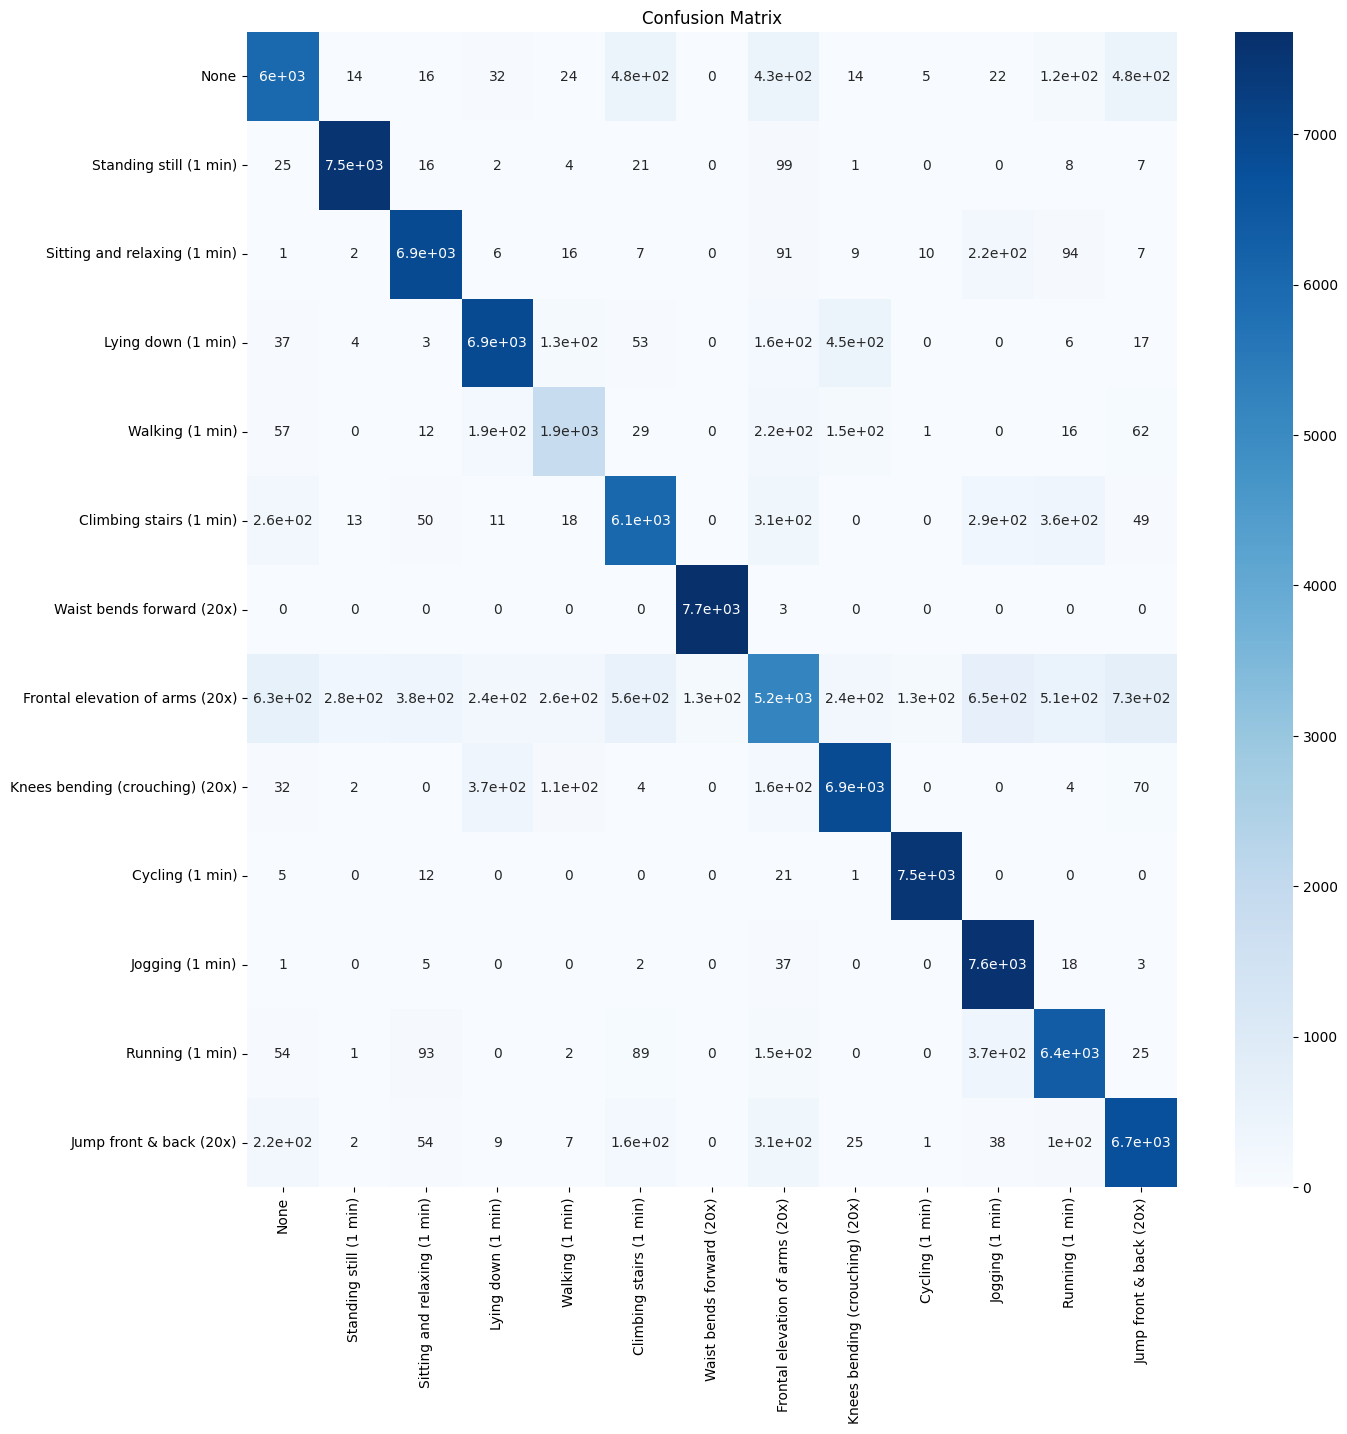

Accuracy Score:  86.9195%
Precision Score: 86.3274%
Recall Score:    86.9792%
F1 Score:        86.4461%


In [ ]:
dt = DecisionTreeClassifier(max_depth=14)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

resultsSummarizer(y_test, y_pred_dt)